In [1]:
import sys

sys.path.append("../src")

from preprocessing import *
from eda import *

In [4]:
"""
Exploratory Data Analysis functions
"""

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


def plot_close(df, ticker):

    plt.figure(figsize=(15,6))

    plt.plot(df.index, df["Close"], linewidth=2)

    plt.title(f"{ticker} Closing Price")

    plt.xlabel("Date")

    plt.ylabel("Price ($)")

    plt.grid(True)

    plt.show()


def plot_returns(df, ticker):

    plt.figure(figsize=(15,6))

    plt.plot(df.index, df["Daily Return"])

    plt.title(f"{ticker} Daily Returns")

    plt.grid(True)

    plt.show()


def plot_rolling(df, ticker):

    plt.figure(figsize=(15,6))

    plt.plot(df["Close"], label="Close")

    plt.plot(df["Rolling Mean"], label="30-Day Mean")

    plt.plot(df["Rolling Std"], label="30-Day Std")

    plt.legend()

    plt.title(f"{ticker} Rolling Statistics")

    plt.grid(True)

    plt.show()


def boxplot_returns(df, ticker):

    plt.figure(figsize=(8,5))

    sns.boxplot(y=df["Daily Return"])

    plt.title(f"{ticker} Daily Return Outliers")

    plt.show()

In [5]:
tsla = load_dataset("../data/processed/TSLA_processed.csv")

spy = load_dataset("../data/processed/SPY_processed.csv")

bnd = load_dataset("../data/processed/BND_processed.csv")

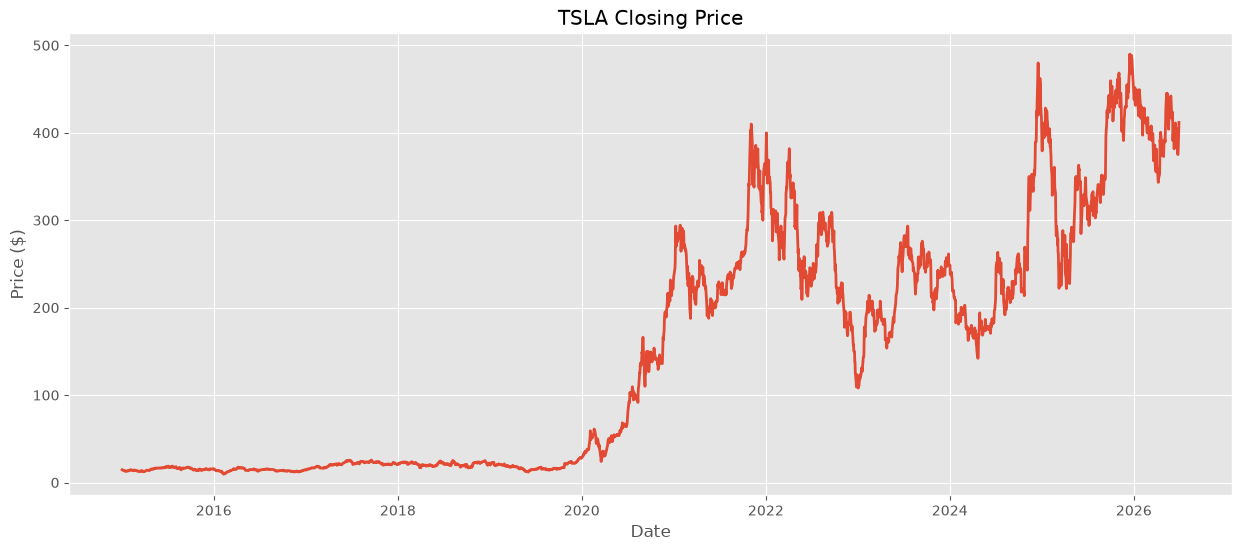

In [6]:
plot_close(tsla,"TSLA")

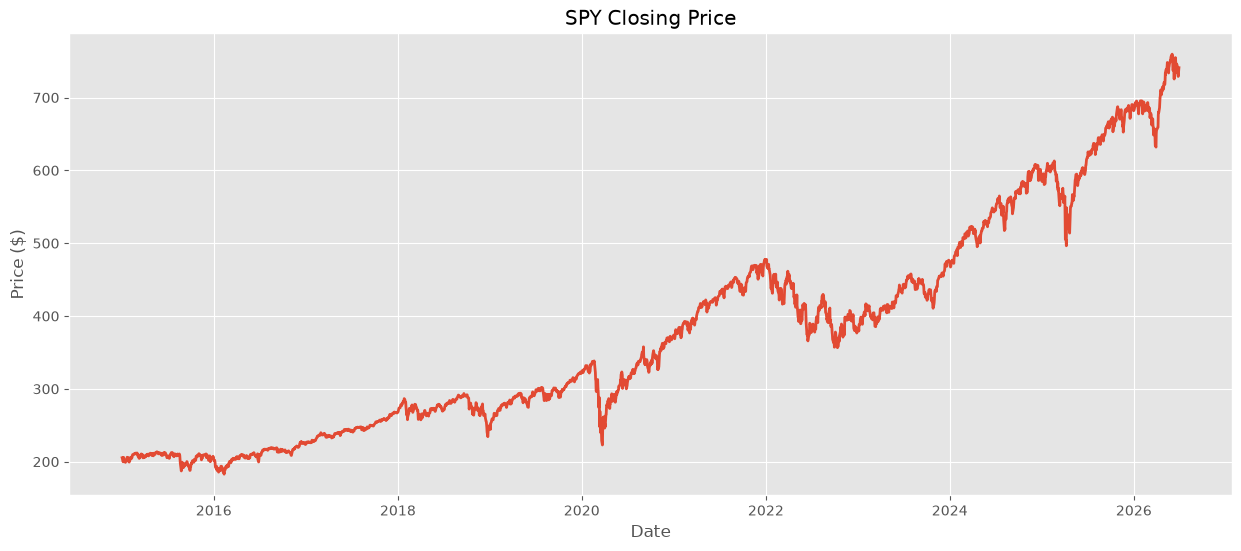

In [7]:
plot_close(spy,"SPY")

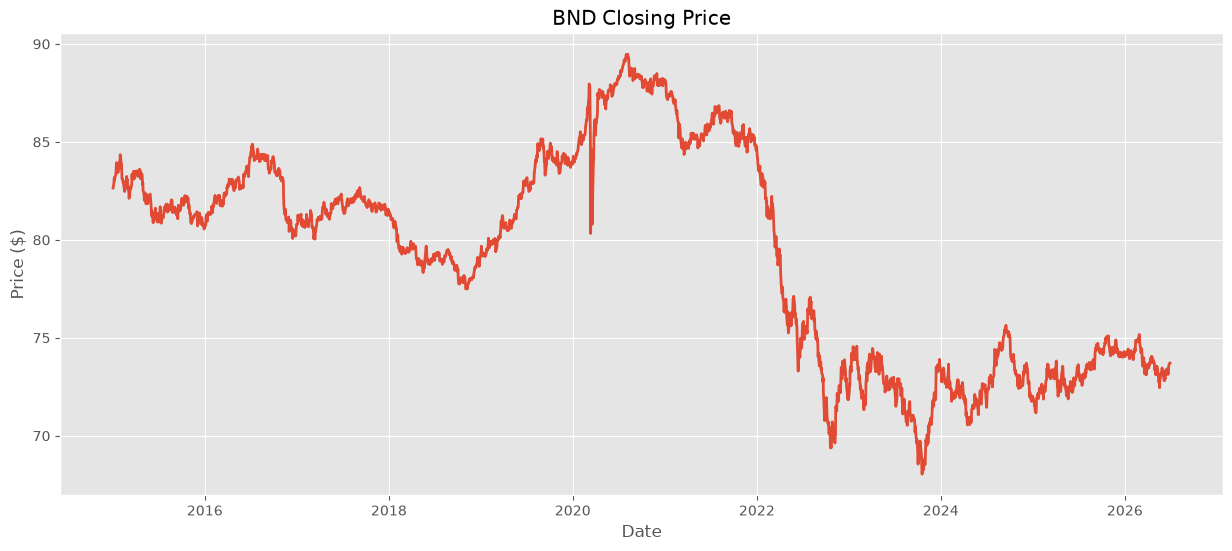

In [8]:
plot_close(bnd,"BND")

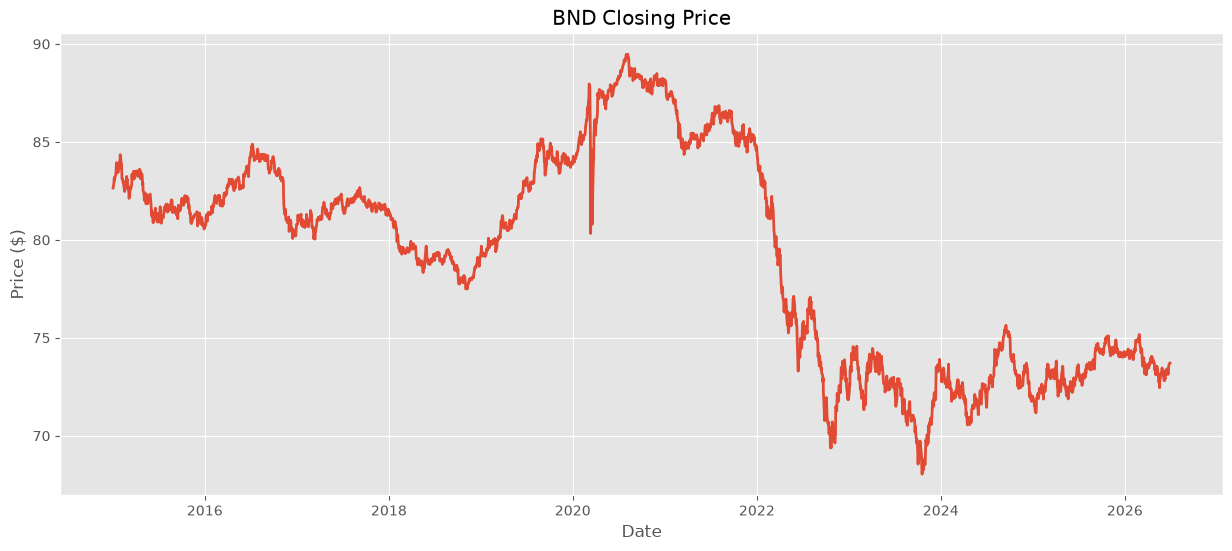

In [9]:
plot_close(bnd,"BND")

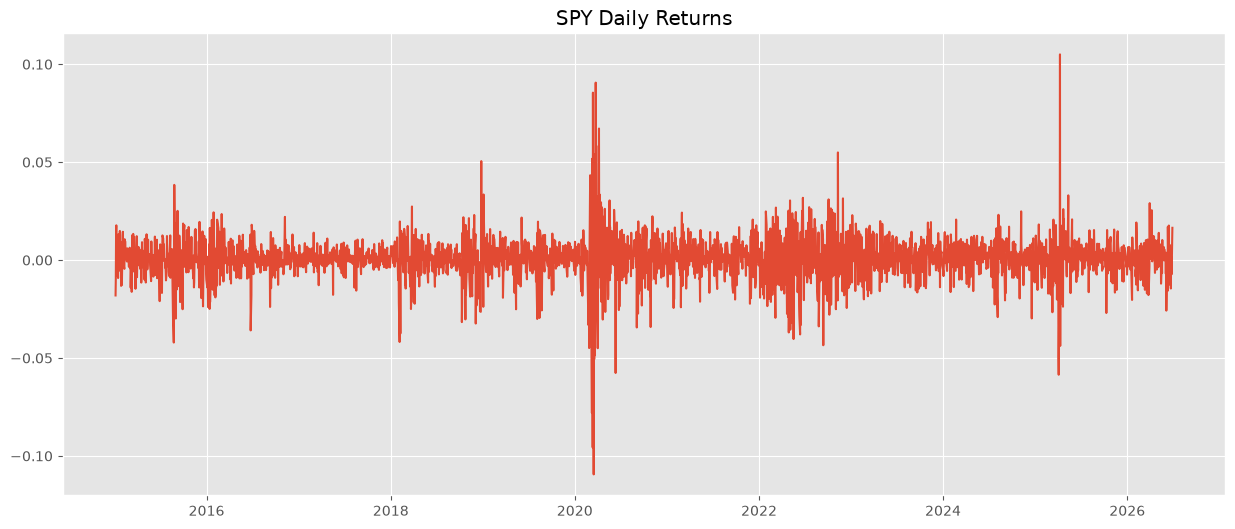

In [10]:
plot_returns(spy,"SPY")

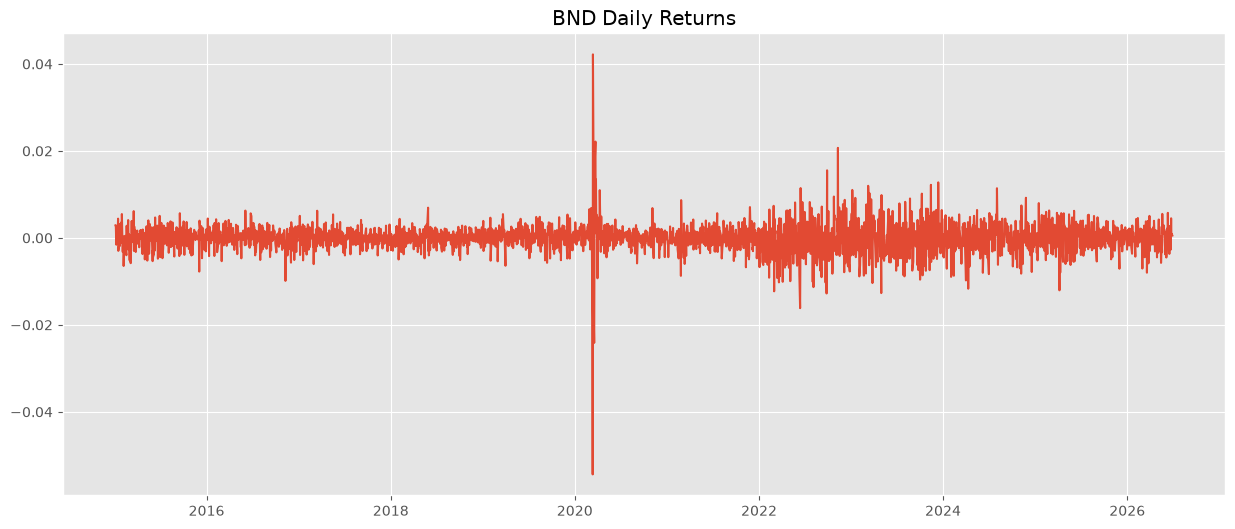

In [11]:
plot_returns(bnd,"BND")

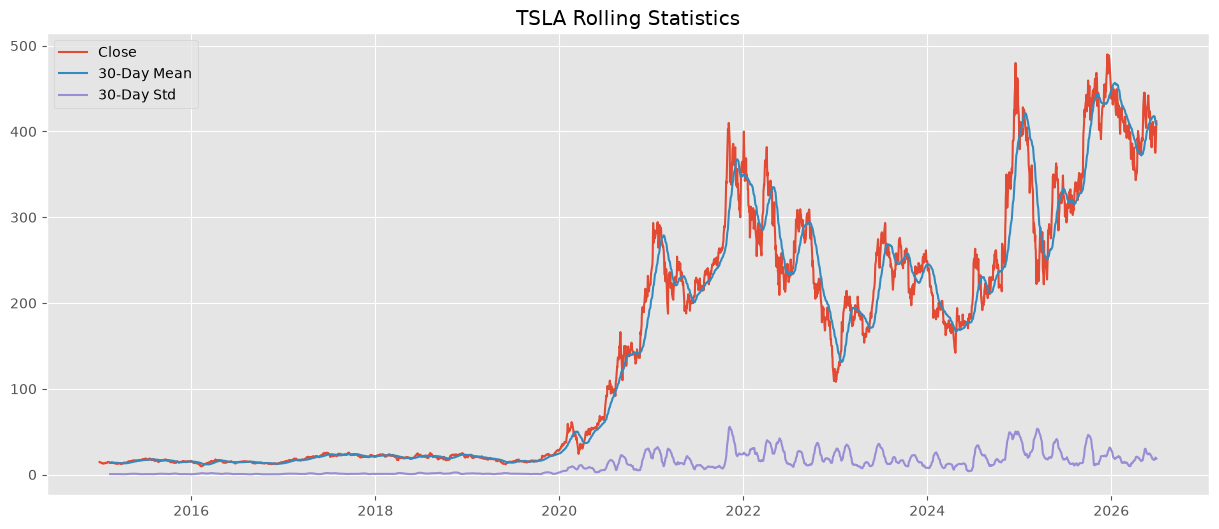

In [12]:
plot_rolling(tsla,"TSLA")

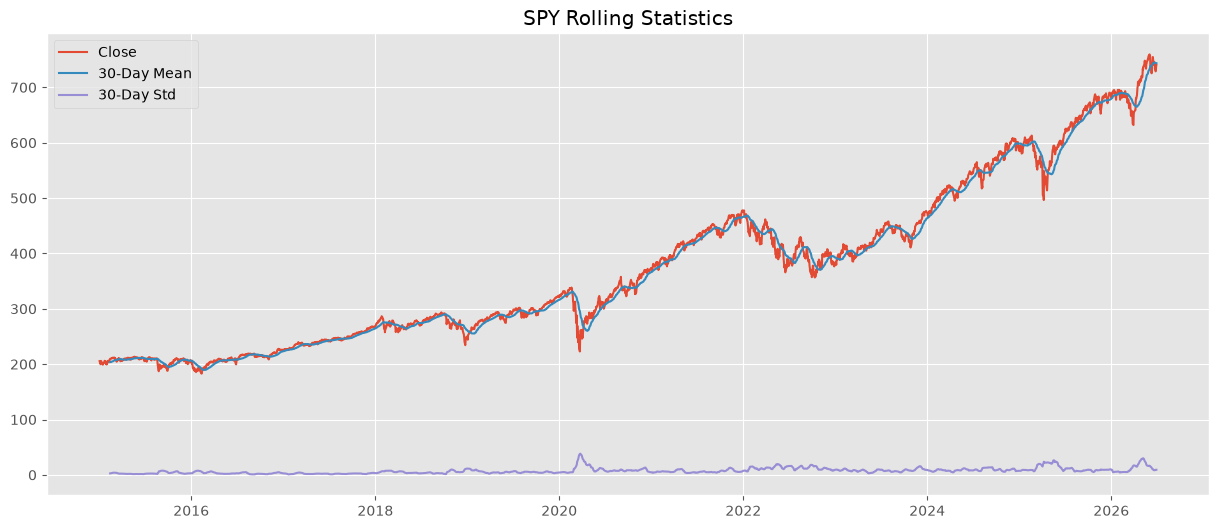

In [13]:
plot_rolling(spy,"SPY")

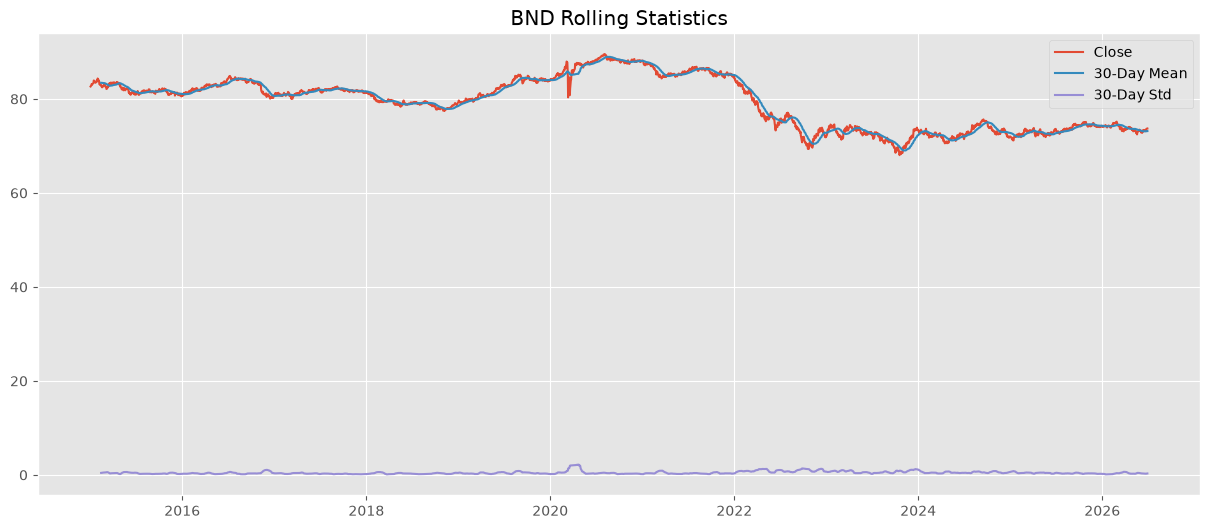

In [15]:
plot_rolling(bnd,"BND")

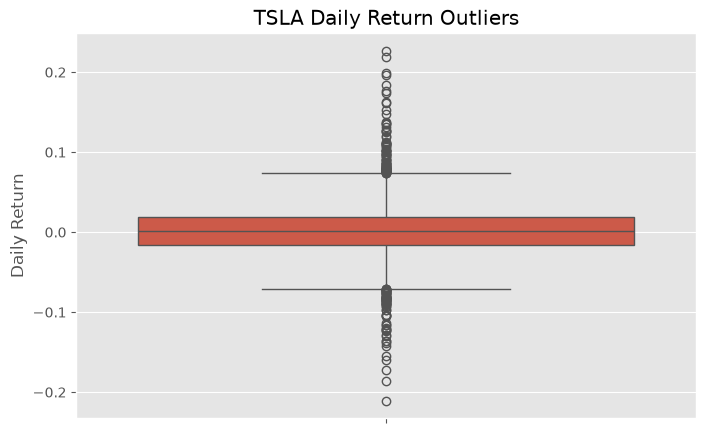

In [16]:
boxplot_returns(tsla,"TSLA")

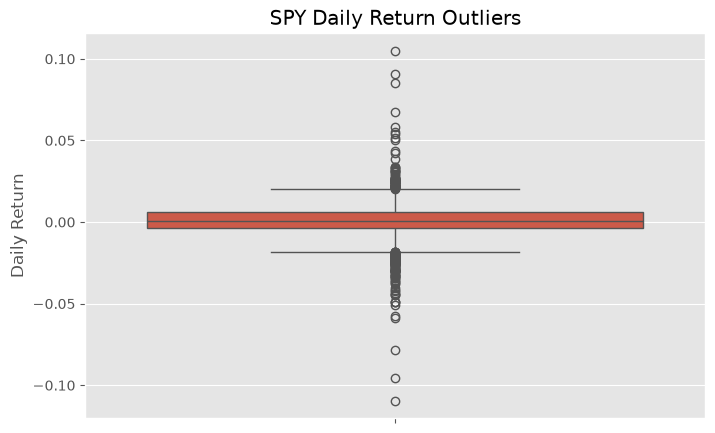

In [17]:
boxplot_returns(spy,"SPY")

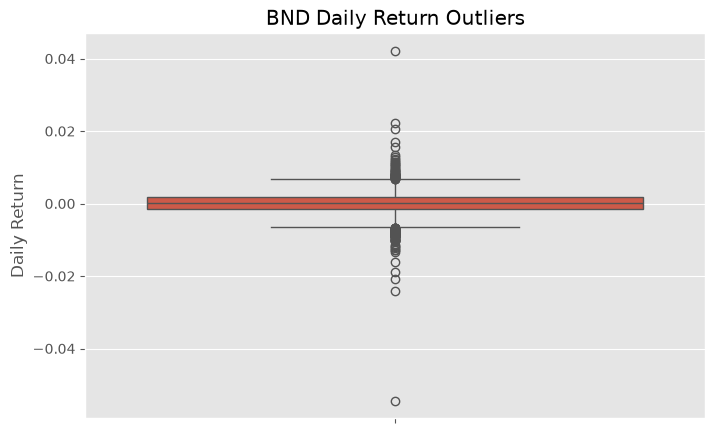

In [18]:
boxplot_returns(bnd,"BND")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [7]:
tsla = pd.read_csv("../data/processed/TSLA_processed.csv")
spy = pd.read_csv("../data/processed/SPY_processed.csv")
bnd = pd.read_csv("../data/processed/BND_processed.csv")

In [8]:
tsla["Date"] = pd.to_datetime(tsla["Date"])
spy["Date"] = pd.to_datetime(spy["Date"])
bnd["Date"] = pd.to_datetime(bnd["Date"])

tsla.set_index("Date", inplace=True)
spy.set_index("Date", inplace=True)
bnd.set_index("Date", inplace=True)

In [9]:
print(tsla.info())
print(spy.info())
print(bnd.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Adj Close     2888 non-null   float64
 1   Close         2888 non-null   float64
 2   High          2888 non-null   float64
 3   Low           2888 non-null   float64
 4   Open          2888 non-null   float64
 5   Volume        2888 non-null   int64  
 6   Daily Return  2887 non-null   float64
 7   Rolling Mean  2859 non-null   float64
 8   Rolling Std   2859 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 225.6 KB
None
<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Adj Close     2888 non-null   float64
 1   Close         2888 non-null   float64
 2   High          2888 non-null   float64
 3   Low           2888 non-n

In [10]:
display(tsla.describe())
display(spy.describe())
display(bnd.describe())

,Adj Close,Close,High,Low,Open,Volume,Daily Return,Rolling Mean,Rolling Std
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000,2859.000000,2859.000000
mean,148.773923,148.773923,151.990563,145.416731,148.797341,1.087922e+08,0.001803,148.179140,11.334277
std,138.895957,138.895957,141.852818,135.867193,138.977191,7.082549e+07,0.036018,137.129881,12.094307
min,9.578000,9.578000,10.331333,9.403333,9.488000,1.062000e+07,-0.210628,11.833911,0.226824
25%,18.393499,18.393499,18.665168,18.023666,18.390833,6.548325e+07,-0.016643,18.906122,0.997314
50%,133.437668,133.437668,136.053329,125.831669,131.496330,9.033615e+07,0.001216,138.275200,8.299088
75%,251.925831,251.925831,257.485008,245.832500,251.680004,1.261204e+08,0.019456,251.098833,18.656602
max,489.880005,489.880005,498.829987,485.329987,489.880005,9.140820e+08,0.226900,456.762003,55.745641


,Adj Close,Close,High,Low,Open,Volume,Daily Return,Rolling Mean,Rolling Std
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000,2859.000000,2859.000000
mean,351.505531,375.216714,377.167216,372.946586,375.149543,8.551049e+07,0.000507,374.230212,7.283332
std,155.443935,146.584697,147.244714,145.774814,146.558911,4.338553e+07,0.011163,144.199280,5.130103
min,154.161606,182.860001,184.100006,181.020004,182.339996,2.027000e+07,-0.109424,189.568333,0.898453
25%,223.546841,254.559998,255.919998,252.477497,254.577503,5.836455e+07,-0.003772,257.290332,3.623517
50%,312.817917,339.435013,342.315002,337.165009,339.835007,7.541950e+07,0.000603,338.795003,6.302856
75%,432.806870,453.677498,456.000000,451.549988,453.989990,9.882245e+07,0.005920,448.716334,9.232806
max,757.618225,759.570007,760.400024,756.750000,758.150024,5.072443e+08,0.105019,744.810665,38.279703


,Adj Close,Close,High,Low,Open,Volume,Daily Return,Rolling Mean,Rolling Std
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000,2859.000000,2859.000000
mean,66.503052,79.327722,79.442119,79.211198,79.330661,4.653786e+06,-0.000034,79.337702,0.457577
std,4.713606,5.310424,5.298010,5.322546,5.313805,3.017704e+06,0.003383,5.284501,0.300550
min,58.729229,68.040001,68.379997,67.989998,68.080002,0.000000e+00,-0.054385,69.031667,0.107117
25%,62.478062,73.800003,73.919998,73.639999,73.800003,2.233700e+06,-0.001635,73.684167,0.263439
50%,65.728390,80.814999,80.905003,80.709999,80.800003,4.280650e+06,0.000119,80.802667,0.372268
75%,70.689133,83.440002,83.550003,83.332500,83.470001,6.246475e+06,0.001715,83.424500,0.540737
max,74.832893,89.480003,89.589996,89.440002,89.550003,3.396300e+07,0.042201,88.965333,2.193878


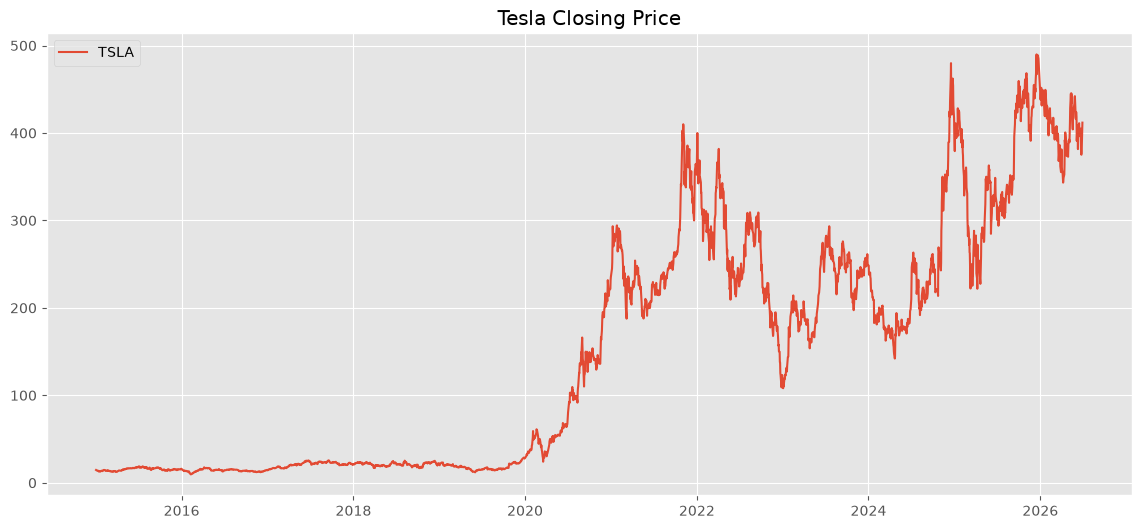

In [11]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(tsla.index, tsla["Close"], label="TSLA")
ax.set_title("Tesla Closing Price")
ax.legend()
plt.show()

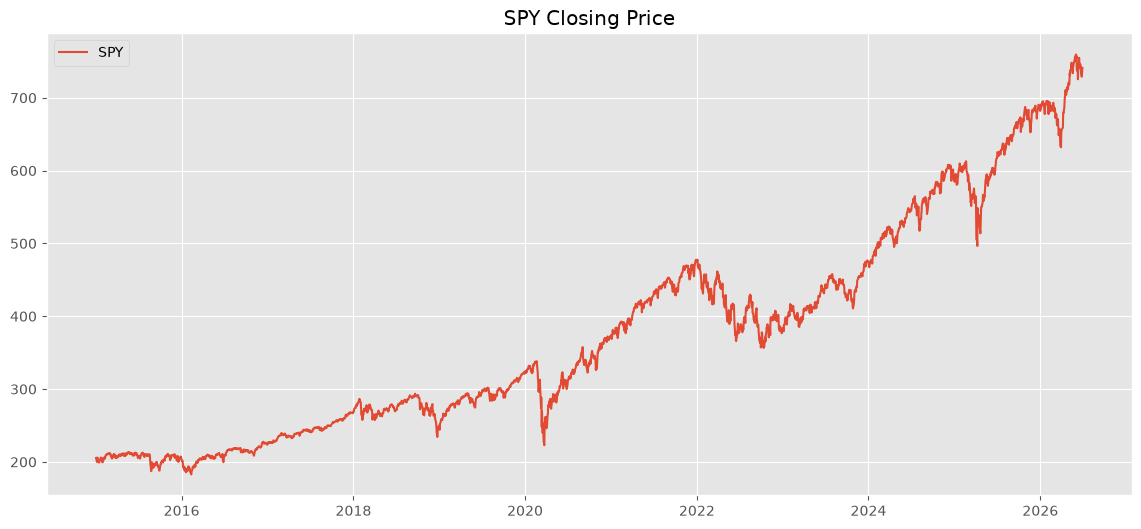

In [12]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(spy.index, spy["Close"], label="SPY")
ax.set_title("SPY Closing Price")
ax.legend()
plt.show()

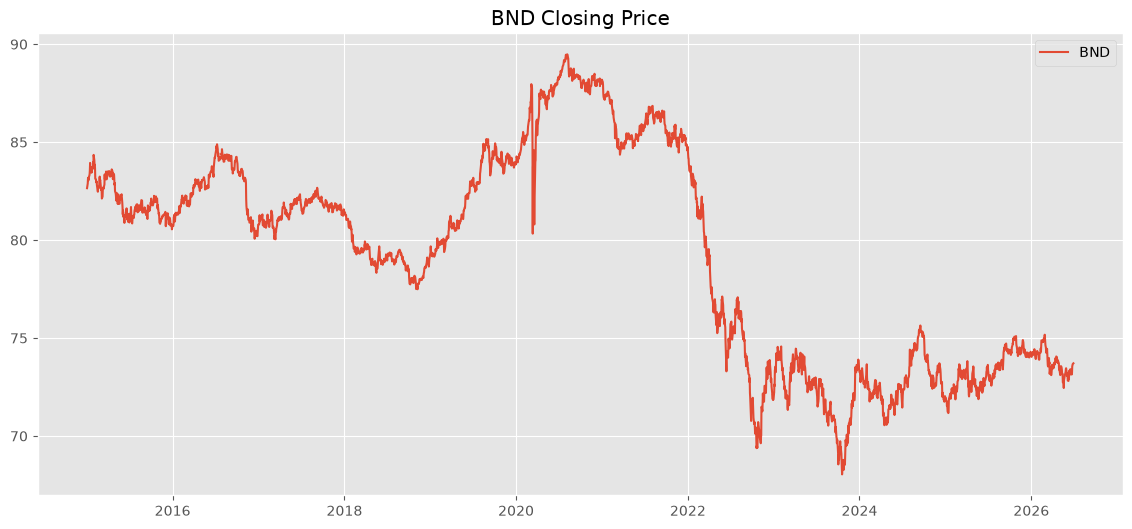

In [13]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(bnd.index, bnd["Close"], label="BND")
ax.set_title("BND Closing Price")
ax.legend()
plt.show()

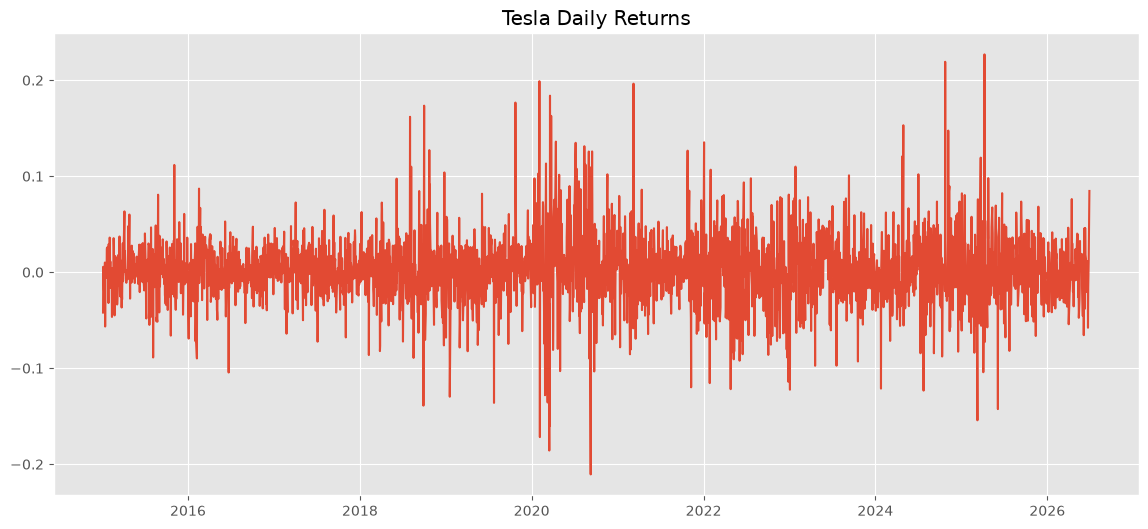

In [14]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(tsla.index, tsla["Daily Return"])
ax.set_title("Tesla Daily Returns")
plt.show()

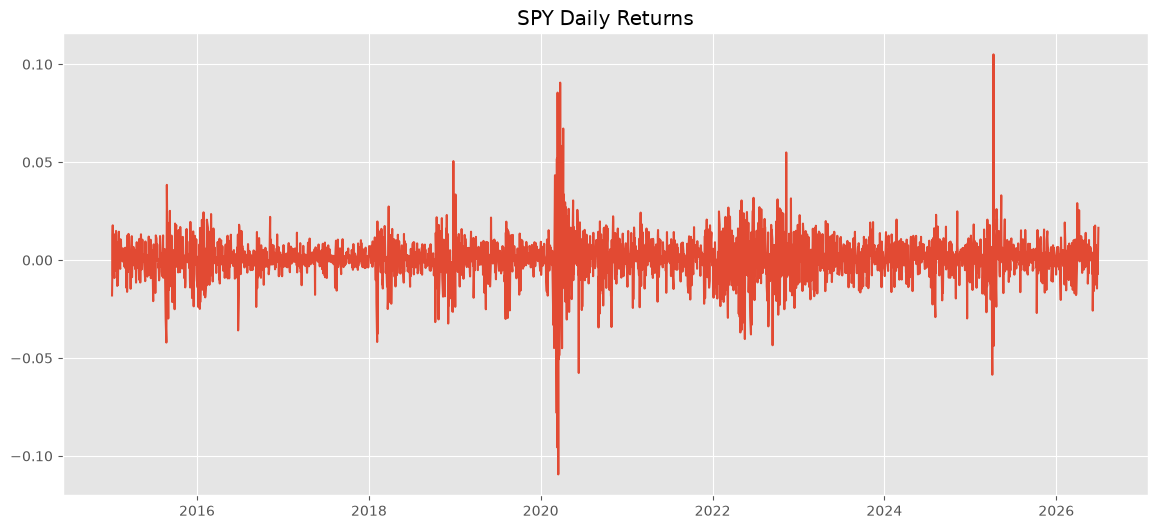

In [15]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(spy.index, spy["Daily Return"])
ax.set_title("SPY Daily Returns")
plt.show()

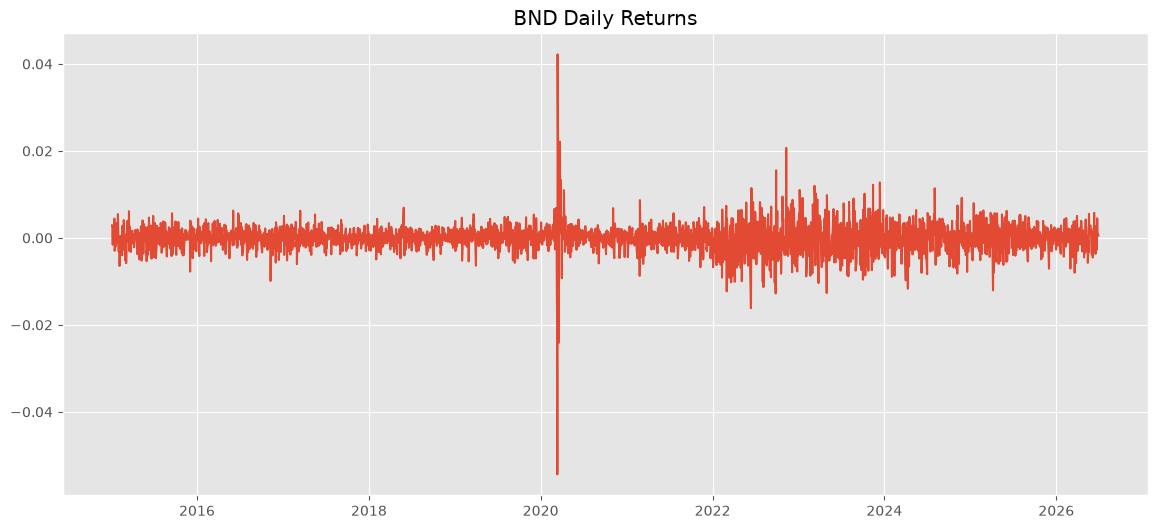

In [16]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(bnd.index, bnd["Daily Return"])
ax.set_title("BND Daily Returns")
plt.show()

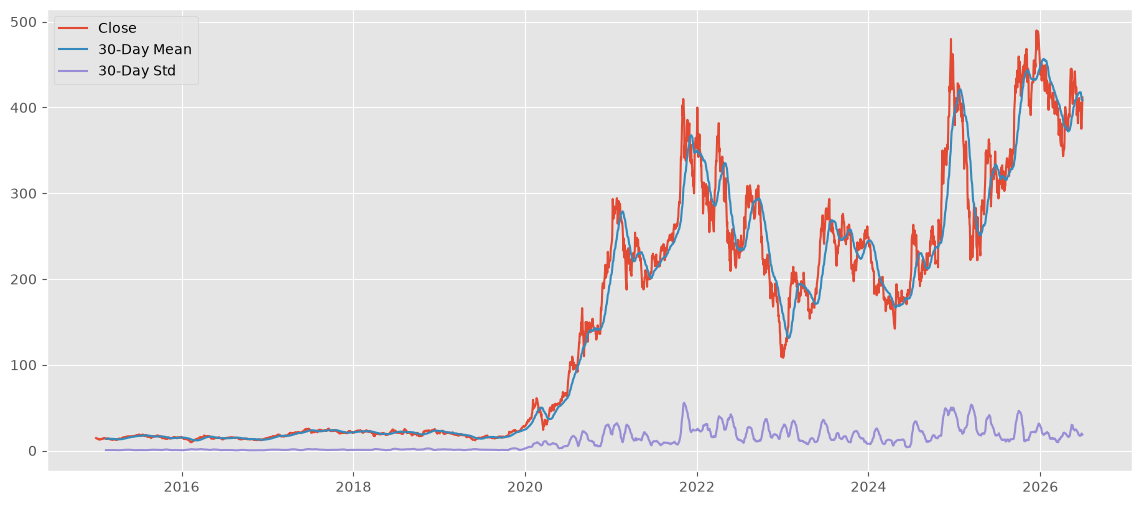

In [17]:
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(tsla["Close"], label="Close")
ax.plot(tsla["Rolling Mean"], label="30-Day Mean")
ax.plot(tsla["Rolling Std"], label="30-Day Std")

ax.legend()
plt.show()

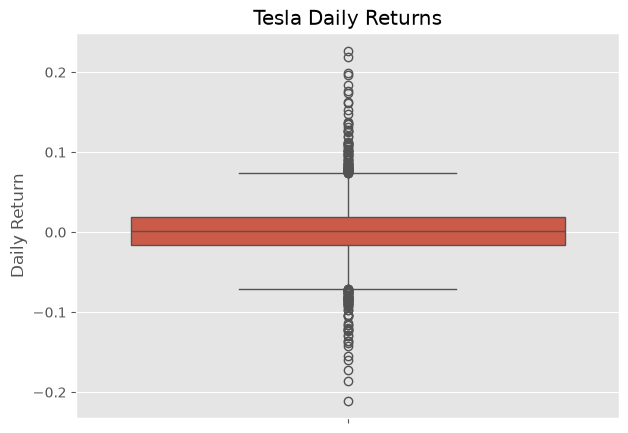

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(y=tsla["Daily Return"])
plt.title("Tesla Daily Returns")
plt.show()

In [19]:
returns = pd.DataFrame({
    "TSLA": tsla["Daily Return"],
    "SPY": spy["Daily Return"],
    "BND": bnd["Daily Return"]
})

returns.corr()

,TSLA,SPY,BND
TSLA,1.000000,0.491456,0.058409
SPY,0.491456,1.000000,0.109867
BND,0.058409,0.109867,1.000000


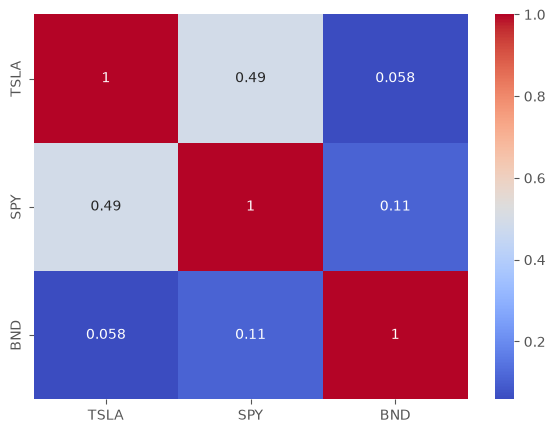

In [20]:
plt.figure(figsize=(7,5))
sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [21]:
def adf_test(series):

    result = adfuller(series.dropna())

    print("ADF Statistic:", result[0])
    print("P-value:", result[1])

    for key, value in result[4].items():
        print(key, value)

In [22]:
print("Tesla Close")
adf_test(tsla["Close"])

print("Tesla Daily Return")
adf_test(tsla["Daily Return"])

Tesla Close
ADF Statistic: -1.0695991394177435
P-value: 0.7270419411549232
1% -3.432638524105552
5% -2.8625511137463935
10% -2.567308245513228
Tesla Daily Return
ADF Statistic: -53.97189280425144
P-value: 0.0
1% -3.4326178883893763
5% -2.862541999961805
10% -2.567303393388591


In [23]:
def value_at_risk(df):

    return np.percentile(
        df["Daily Return"].dropna(),
        5
    )

In [24]:
def sharpe_ratio(df):

    rf = 0.02/252

    excess = df["Daily Return"]-rf

    return np.sqrt(252)*excess.mean()/excess.std()